In [49]:
import os 
os.chdir('/workspaces/my-project/')

in questo Notebook, inserisco i quattro dataset di train per analizzarli, iniziando a notare alcune relazioni

# Appunti sul Dataset FD001 train

Il primo sotto-set simula lo scenario più semplice e controllato di tutto C-MAPSS. 

### Condizioni di volo
I motori lavorano tutti in una singola condizione operativa (volo stabilizzato a livello del mare).
* **Altezza** e **Velocità** sono fisse a zero (con minime oscillazioni dovute al rumore intrinseco dei sensori).
* La posizione della manetta del gas (TRA - Throttle Resolver Angle) è costantemente bloccata a **100.0**. iene simulato il motore che spinge sempre al massimo.

### Comportamento dei motori
*Tutti i 100 motori si rompono esclusivamente per il degrado del **Compressore ad Alta Pressione (HPC)**.
* **I dati di Train:** Abbiamo a disposizione la storia completa di 100 motori. Ognuno parte in buono stato (con un'usura iniziale minima e casuale inferiore all'1%) e viene tracciato ciclo dopo ciclo fino a quando non si rompe definitivamente. L'ultima riga di ogni motore coincide con il proprio punto di guasto.


In [50]:
import pandas as pd
pd.set_option('display.max_columns', None)

# Definiamo i nomi delle 26 colonne indicati nella documentazione pdf
nomi_colonne = [
    'id_motore', 'ciclo', 'altitudine', 'velocita_mach', 'manetta_tra',
    "Temperatura all'ingresso del fan", 
    "Temperatura totale all'uscita del LPC", 
    "Temperatura all'uscita di HCP", 
    "Temperatura all'uscita di LPT", 
    "Pressione all'ingresso del FAN",
    'Pressione nel condotto di bypass', 
    "Pressione all'uscita di HPC", 
    'Velocità del FAN', 
    'Velocità del nucleo', 
    'Rapporto di pressione del motore',
    "Pressione statica all'uscita dell'HPC", 
    'Rapporto tra portata di combustibile e ps30', 
    'Velocità corretta del fan', 
    'Velocità corretta del nucleo',
    'Rapporto di bypass',
    'Rapporto aria-combustibile nel combustore', 
    'Entalpia di spillamento', 
    'Velocità del FAN richiesta', 
    'Velocità corretta del fan richiesta',
    'Spillamento del refrigerante HPT',
    'Spillamento del refrigerante LPT'
]

# Carichiamo il dataset 
df_train = pd.read_csv('data/train_FD001.txt', sep=r'\s+', names=nomi_colonne, header=None)
display(df_train.head())

,id_motore,ciclo,altitudine,velocita_mach,manetta_tra,Temperatura all'ingresso del fan,Temperatura totale all'uscita del LPC,Temperatura all'uscita di HCP,Temperatura all'uscita di LPT,Pressione all'ingresso del FAN,Pressione nel condotto di bypass,Pressione all'uscita di HPC,Velocità del FAN,Velocità del nucleo,Rapporto di pressione del motore,Pressione statica all'uscita dell'HPC,Rapporto tra portata di combustibile e ps30,Velocità corretta del fan,Velocità corretta del nucleo,Rapporto di bypass,Rapporto aria-combustibile nel combustore,Entalpia di spillamento,Velocità del FAN richiesta,Velocità corretta del fan richiesta,Spillamento del refrigerante HPT,Spillamento del refrigerante LPT
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


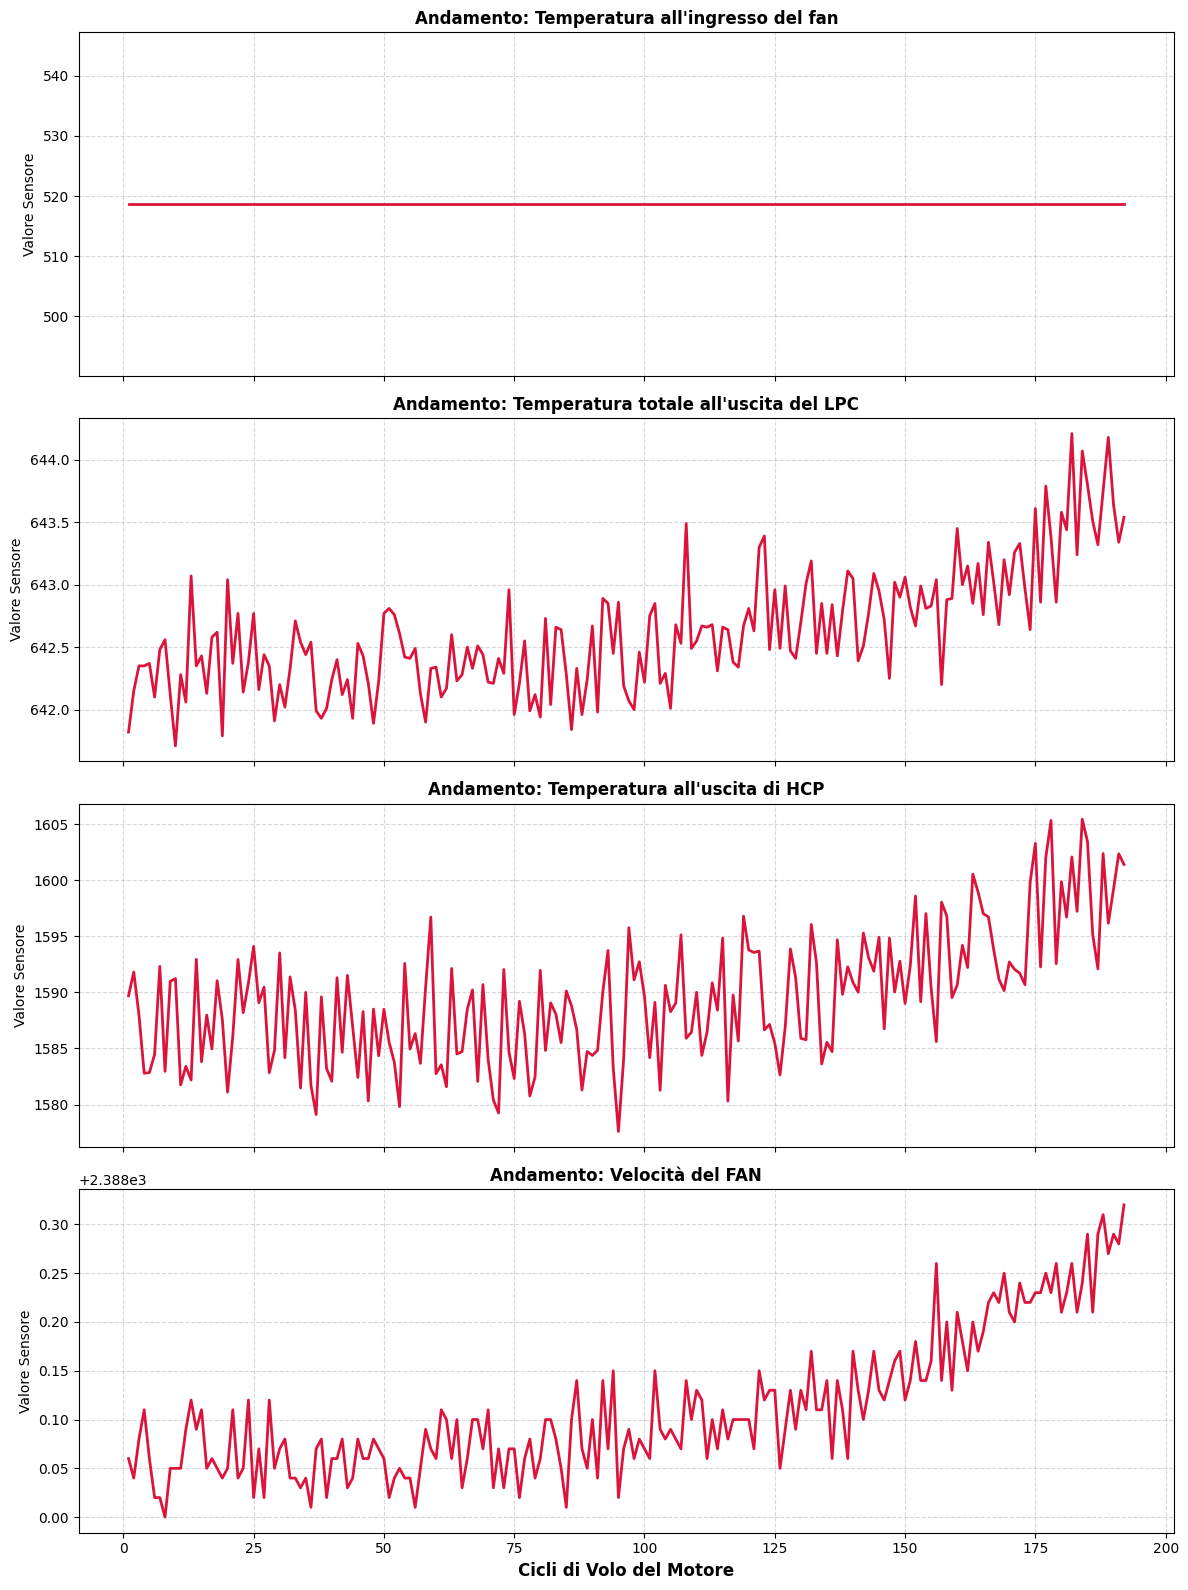

In [51]:
import matplotlib.pyplot as plt

# Isoliamo i dati relativi al primo motore con id=1
motore_1 = df_train[df_train['id_motore'] == 1]

#Grafico alcuni sensori per il confronto
# Prendiamo sensori che variano (es. temperature e velocità) e uno piatto (ingresso del fan)
sensori_da_graficare = [
    "Temperatura all'ingresso del fan",          # Vedremo che è costante
    "Temperatura totale all'uscita del LPC",     # Cambierà col degrado
    "Temperatura all'uscita di HCP",             # Cambierà col degrado
    "Velocità del FAN"                           # Cambierà col degrado
]

# questa è la griglia dei grafici (4x1)
fig, assi = plt.subplots(nrows=4, ncols=1, figsize=(12, 16), sharex=True)

for i, nome_sensore in enumerate(sensori_da_graficare):
    # Disegniamo la linea del sensore al variare dei cicli
    assi[i].plot(motore_1['ciclo'], motore_1[nome_sensore], color='crimson', linewidth=2)
    
    #titolo del grafico
    assi[i].set_title(f"Andamento: {nome_sensore}", fontsize=12, fontweight='bold')
    assi[i].set_ylabel("Valore Sensore")
    assi[i].grid(True, linestyle='--', alpha=0.5)

# Configurazione dell'asse X finale 
assi[-1].set_xlabel("Cicli di Volo del Motore", fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

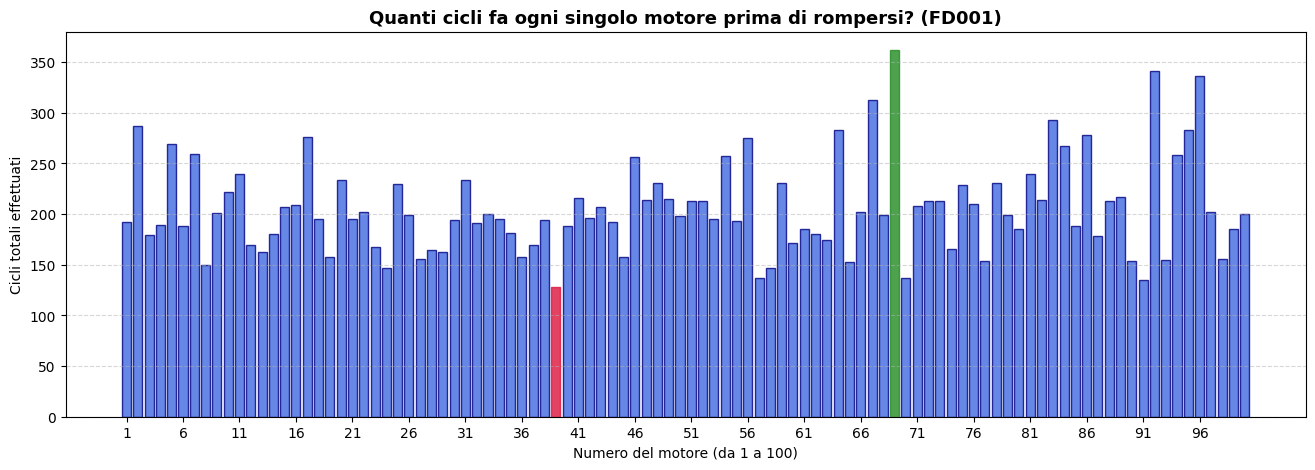

Riepilogo dei dati:
- Il motore che è durato MENO è il numero 39 (si è rotto a 128 cicli).
- Il motore che è durato DI PIÙ è il numero 69 (è arrivato a 362 cicli).
- In media, i motori resistono per 206.3 cicli.


In [52]:
import matplotlib.pyplot as plt

#  durata massima (ultimo ciclo) per ogni motore
durata_motori = df_train.groupby('id_motore')['ciclo'].max()

# motore migliore e peggiore in base alla durata
motore_piu_corto = durata_motori.idxmin()
cicli_min = durata_motori.min()

motore_piu_lungo = durata_motori.idxmax()
cicli_max = durata_motori.max()

media_cicli = durata_motori.mean()

#grafico a barre
plt.figure(figsize=(16, 5))

# diagramma a barre con tutti i motori, colorati di blu 
barre = plt.bar(durata_motori.index, durata_motori.values, color='royalblue', edgecolor='navy', alpha=0.8)

# Coloriamo il peggiore di rosso e il migliore di verde per farli notare subito
barre[motore_piu_corto - 1].set_color('crimson')
barre[motore_piu_lungo - 1].set_color('forestgreen')


plt.title("Quanti cicli fa ogni singolo motore prima di rompersi? (FD001)", fontsize=13, fontweight='bold')
plt.xlabel("Numero del motore (da 1 a 100)")
plt.ylabel("Cicli totali effettuati")

# Mostriamo un numero ogni 5 sull'asse X così si legge bene
plt.xticks(range(1, 101, 5))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

# 4. Stampiamo i risultati
print("Riepilogo dei dati:")
print(f"- Il motore che è durato MENO è il numero {motore_piu_corto} (si è rotto a {cicli_min} cicli).")
print(f"- Il motore che è durato DI PIÙ è il numero {motore_piu_lungo} (è arrivato a {cicli_max} cicli).")
print(f"- In media, i motori resistono per {media_cicli:.1f} cicli.")

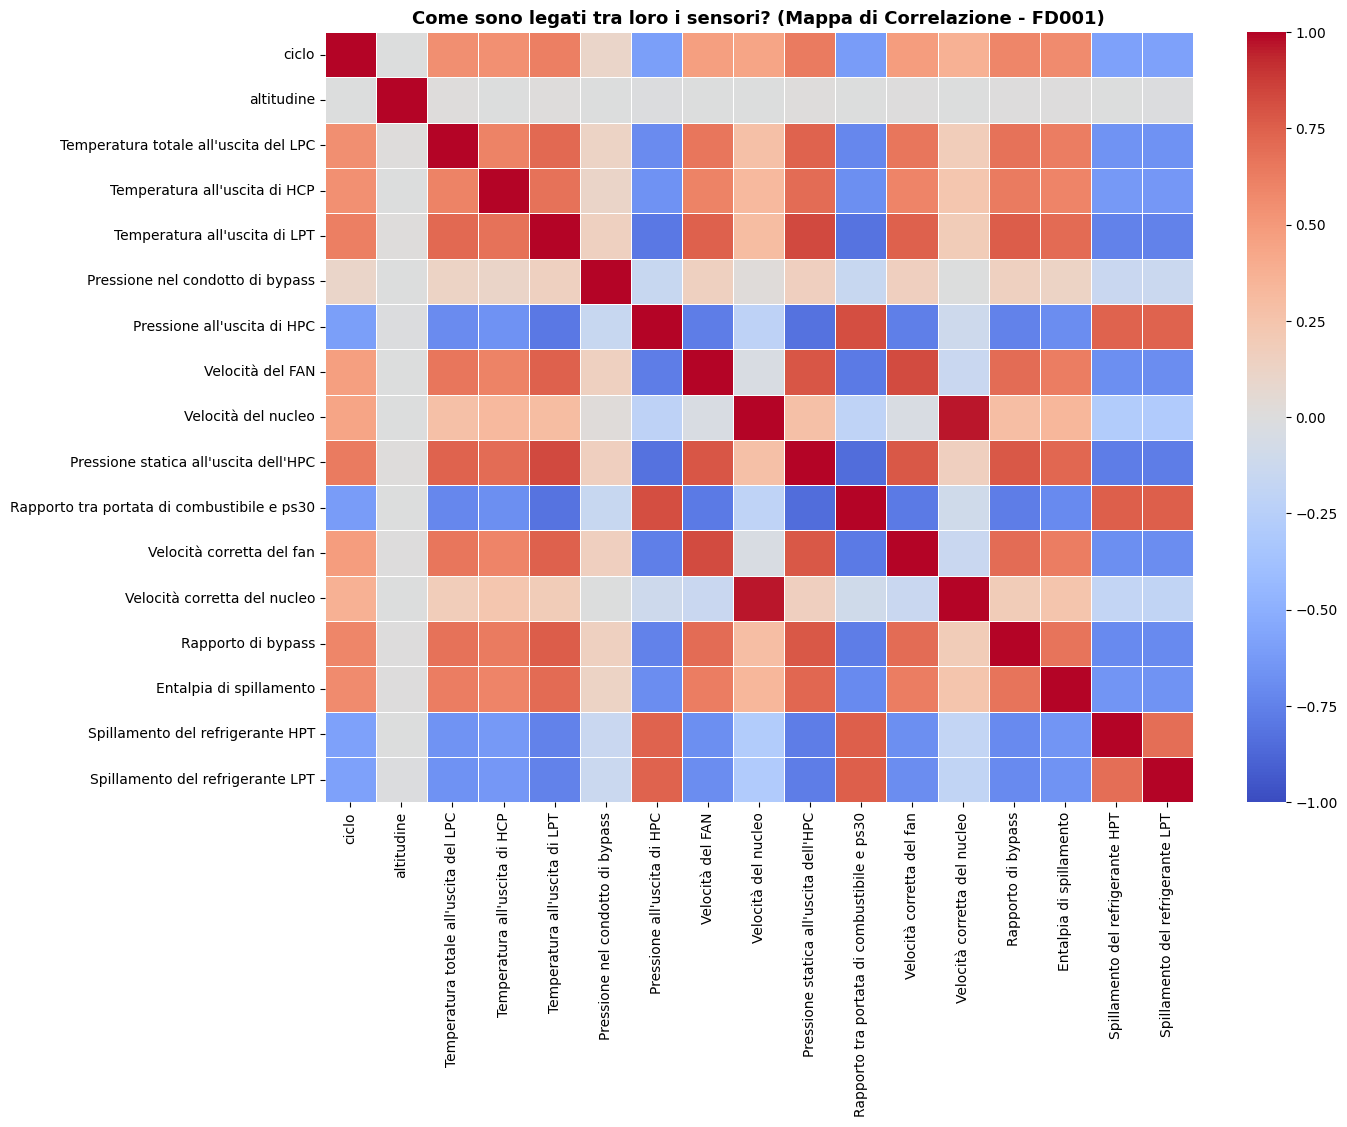

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Troviamo ed escludiamo i sensori che rimangono piatti (varianza quasi a zero)
deviazioni = df_train.std()
colonne_attive = deviazioni[deviazioni > 0.001].index.tolist()

# Escludiamo l'id_motore perché è solo un numero identificativo, non una misura
if 'id_motore' in colonne_attive:
    colonne_attive.remove('id_motore')

# 2. Creiamo la matrice di correlazione solo sui sensori che variano davvero
matrice_corr = df_train[colonne_attive].corr()

# 3. Disegnamo la mappa di calore
plt.figure(figsize=(14, 10))
sns.heatmap(matrice_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title("Come sono legati tra loro i sensori? (Mappa di Correlazione - FD001)", fontsize=13, fontweight='bold')
plt.show()

L'analisi della matrice di correlazione mostra che il progressivo aumento dei cicli di volo (degrado) è fortemente legato all'innalzamento dei parametri termici (LPC, HPC, LPT) e all'aumento della velocità del FAN, a fronte di un crollo della pressione di scarico dell'HPC. I sensori costanti come l'altitudine mostrano correlazione nulla e verranno esclusi dal modello

# APPUNTI SUL DATASET FD002 TRAIN



In questo dataset di train le cose si complicano e vengono simulate condizioni molto più simili a quelle dei voli reali.

### Ci sono 6 regimi di volo
Qui i motori operano muovendosi continuamente tra **6 condizioni operative diverse** (combinazioni diverse di quota, velocità e potenza della manetta). 
 Da un ciclo all'altro l'aereo può passare dal decollo a livello del mare alla crociera ad alta quota.

In questo caso, tutti i sensori avranno dei balzi improvvisi. Questo è dovuto molto spesso sia alle variazioni delle condizioni di volo sia al degrado che inizia ad arrivare. Per questo sarà molto difficile prevederlo. 

### Rottura
* **Il guasto:** Dal punto di vista meccanico, tutti i motori si rompono per il degrado del **Compressore ad Alta Pressione (HPC)**, come nel dataset di train fd001.
* Per gestire questa complessità, i motori analizzati aumentano. In questo file abbiamo la storia completa di ben **260 motori** (invece di 100). Ognuno parte in buono stato e viene tracciato fino al guasto totale.

In [54]:
import pandas as pd
pd.set_option('display.max_columns', None)

# Definiamo i nomi delle 26 colonne indicati nella documentazione pdf
nomi_colonne = [
    'id_motore', 'ciclo', 'altitudine', 'velocita_mach', 'manetta_tra',
    "Temperatura all'ingresso del fan", 
    "Temperatura totale all'uscita del LPC", 
    "Temperatura all'uscita di HCP", 
    "Temperatura all'uscita di LPT", 
    "Pressione all'ingresso del FAN",
    'Pressione nel condotto di bypass', 
    "Pressione all'uscita di HPC", 
    'Velocità del FAN', 
    'Velocità del nucleo', 
    'Rapporto di pressione del motore',
    "Pressione statica all'uscita dell'HPC", 
    'Rapporto tra portata di combustibile e ps30', 
    'Velocità corretta del fan', 
    'Velocità corretta del nucleo',
    'Rapporto di bypass',
    'Rapporto aria-combustibile nel combustore', 
    'Entalpia di spillamento', 
    'Velocità del FAN richiesta', 
    'Velocità corretta del fan richiesta',
    'Spillamento del refrigerante HPT',
    'Spillamento del refrigerante LPT'
]

# Carichiamo il dataset 
df_train = pd.read_csv('data/train_FD002.txt', sep=r'\s+', names=nomi_colonne, header=None)
display(df_train.head())

,id_motore,ciclo,altitudine,velocita_mach,manetta_tra,Temperatura all'ingresso del fan,Temperatura totale all'uscita del LPC,Temperatura all'uscita di HCP,Temperatura all'uscita di LPT,Pressione all'ingresso del FAN,Pressione nel condotto di bypass,Pressione all'uscita di HPC,Velocità del FAN,Velocità del nucleo,Rapporto di pressione del motore,Pressione statica all'uscita dell'HPC,Rapporto tra portata di combustibile e ps30,Velocità corretta del fan,Velocità corretta del nucleo,Rapporto di bypass,Rapporto aria-combustibile nel combustore,Entalpia di spillamento,Velocità del FAN richiesta,Velocità corretta del fan richiesta,Spillamento del refrigerante HPT,Spillamento del refrigerante LPT
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,8.00,194.64,2222.65,8341.91,1.02,42.02,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,5.71,138.51,2211.57,8303.96,1.02,42.20,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,9.02,175.71,1915.11,8001.42,0.94,36.69,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,5.71,138.46,2211.58,8303.96,1.02,41.96,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,9.03,175.05,1915.10,7993.23,0.94,36.89,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


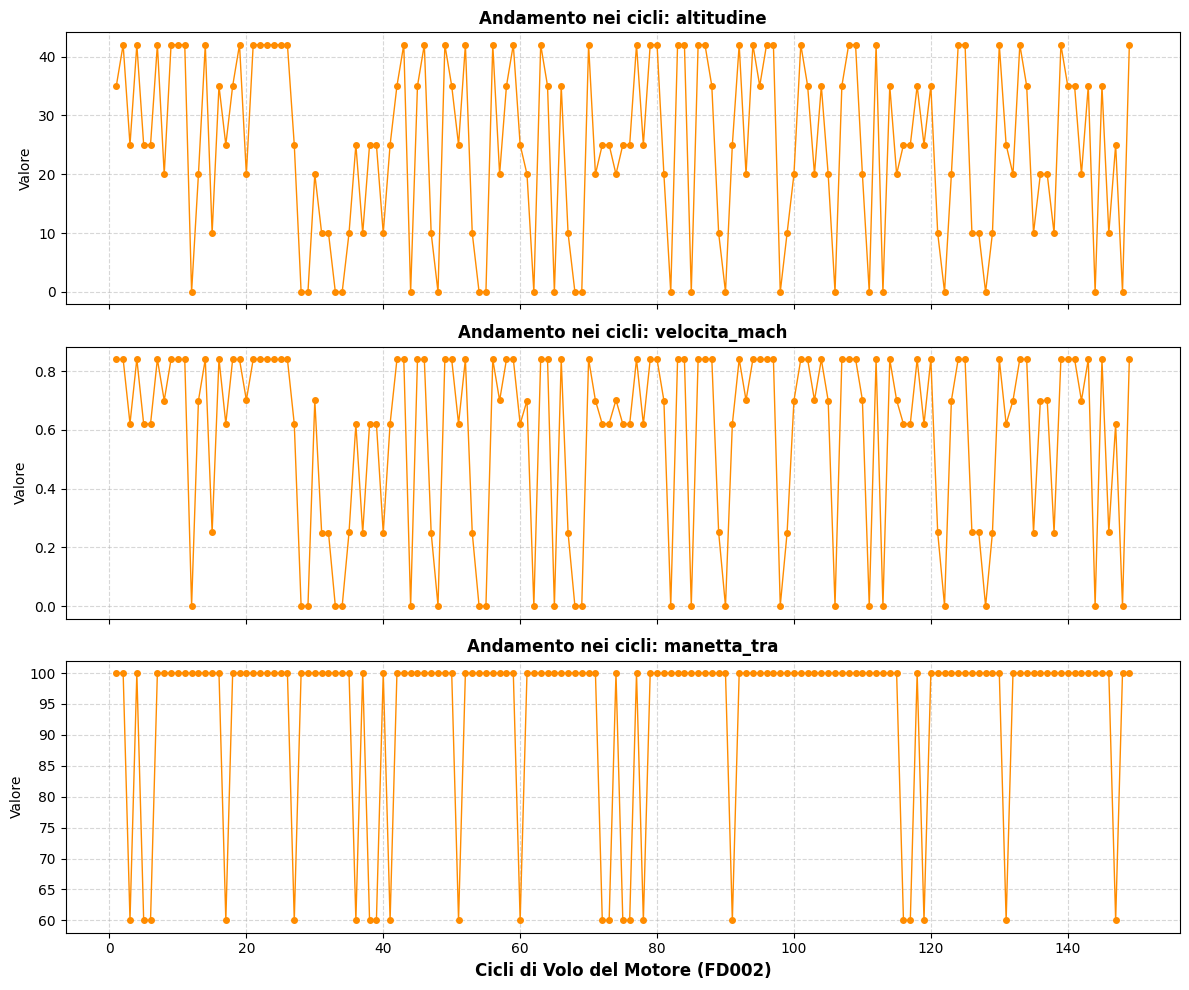

In [55]:
import matplotlib.pyplot as plt

# 1. Isoliamo i dati relativi solo al primo motore di FD002
motore_1_fd002 = df_train[df_train['id_motore'] == 1]

# 2. Selezioniamo le tre variabili ambientali che definiscono il regime di volo
condizioni_ambientali = ['altitudine', 'velocita_mach', 'manetta_tra']

# 3. Generiamo i grafici
fig, assi = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

for i, var in enumerate(condizioni_ambientali):
    # Usiamo uno stile a punti (scatter) o a linea per vedere i continui sbalzi
    assi[i].plot(motore_1_fd002['ciclo'], motore_1_fd002[var], color='darkorange', marker='o', linestyle='-', markersize=4, linewidth=1)
    
    assi[i].set_title(f"Andamento nei cicli: {var}", fontsize=12, fontweight='bold')
    assi[i].set_ylabel("Valore")
    assi[i].grid(True, linestyle='--', alpha=0.5)

assi[-1].set_xlabel("Cicli di Volo del Motore (FD002)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [56]:
print(f"Il motore 1 di FD002 fa {len(motore_1_fd002)} cicli.")

Il motore 1 di FD002 fa 149 cicli.


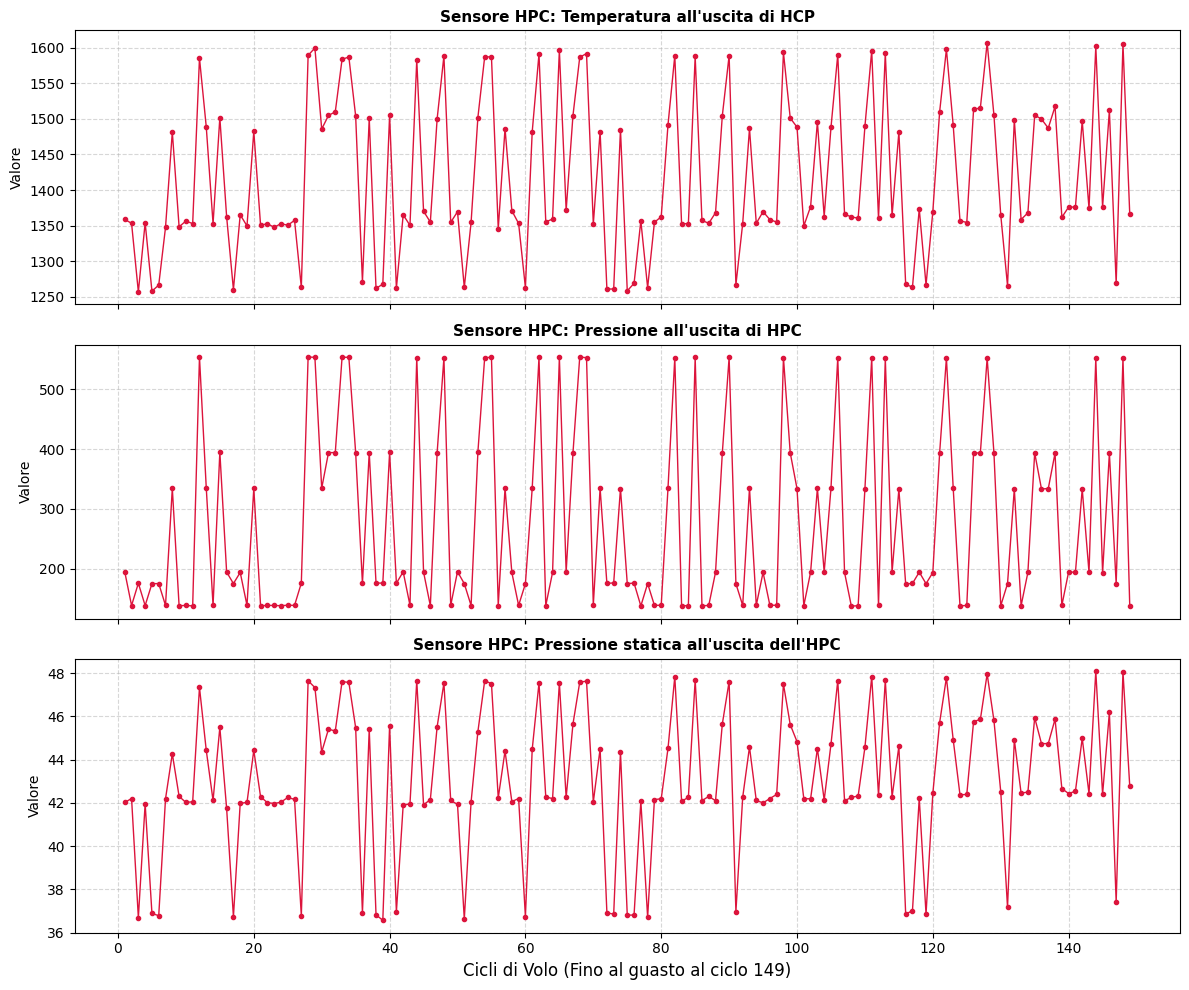

L'andamento dei sensori legati all'HPC nel dataset FD002 mostra forti oscillazioni cicliche
 dovute alla presenza dei 6 regimi operativi (cambi di quota e manetta). Il progressivo degrado del compressore
 non è visibile con un trend lineare isolato.


In [57]:
import matplotlib.pyplot as plt

# Isoliamo il motore 1
motore_1 = df_train[df_train['id_motore'] == 1]

# I 3 sensori chiave del danno all'HPC
sensori_critici = [
    "Temperatura all'uscita di HCP", 
    "Pressione all'uscita di HPC", 
    "Pressione statica all'uscita dell'HPC"
]

# Creiamo i grafici
fig, assi = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

for i, sensore in enumerate(sensori_critici):
    # Grafichiamo i dati grezzi con una linea e i punti
    assi[i].plot(motore_1['ciclo'], motore_1[sensore], color='crimson', marker='o', markersize=3, linewidth=1)
    
    assi[i].set_title(f"Sensore HPC: {sensore}", fontsize=11, fontweight='bold')
    assi[i].set_ylabel("Valore")
    assi[i].grid(True, linestyle='--', alpha=0.5)

assi[-1].set_xlabel("Cicli di Volo (Fino al guasto al ciclo 149)", fontsize=12)

plt.tight_layout()
plt.show()
print("L'andamento dei sensori legati all'HPC nel dataset FD002 mostra forti oscillazioni cicliche\n" \
" dovute alla presenza dei 6 regimi operativi (cambi di quota e manetta). Il progressivo degrado del compressore\n" \
" non è visibile con un trend lineare isolato.")

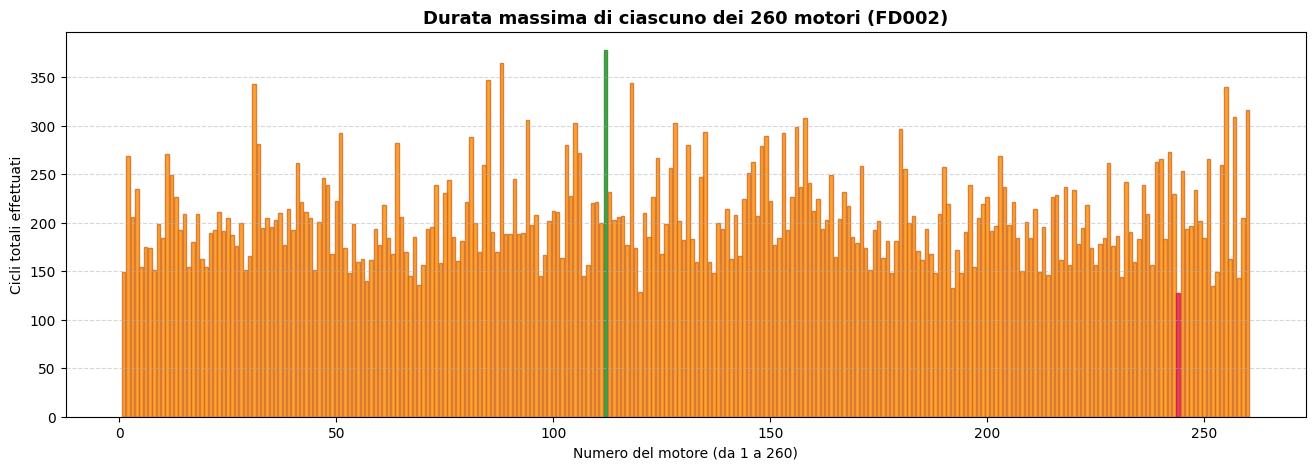

Riepilogo dati flotta FD002:
- Il motore più fragile è il numero 244 (rotto a 128 cicli).
- Il motore più resistente è il numero 112 (arrivato a 378 cicli).
- In media, i motori in FD002 resistono per 206.8 cicli.


In [58]:
import matplotlib.pyplot as plt

#durata max per ogni motore
durata_002 = df_train.groupby('id_motore')['ciclo'].max()

# motore migliore e peggiore e media
motore_min = durata_002.idxmin()
cicli_min = durata_002.min()

motore_max = durata_002.idxmax()
cicli_max = durata_002.max()

media_cicli = durata_002.mean()

#grafico a barre
plt.figure(figsize=(16, 5))
barre = plt.bar(durata_002.index, durata_002.values, color='darkorange', edgecolor='chocolate', alpha=0.8)

#migliore e peggiore evidenziati
barre[motore_min - 1].set_color('crimson')
barre[motore_max - 1].set_color('forestgreen')

plt.title("Durata massima di ciascuno dei 260 motori (FD002)", fontsize=13, fontweight='bold')
plt.xlabel("Numero del motore (da 1 a 260)")
plt.ylabel("Cicli totali effettuati")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

#statistiche
print("Riepilogo dati flotta FD002:")
print(f"- Il motore più fragile è il numero {motore_min} (rotto a {cicli_min} cicli).")
print(f"- Il motore più resistente è il numero {motore_max} (arrivato a {cicli_max} cicli).")
print(f"- In media, i motori in FD002 resistono per {media_cicli:.1f} cicli.")

# Dataset Fd003 train 
Si torna a volare in condizioni più semplici, ma si rompono più cose contemporaneamente.

###  Condizioni di volo
Dal punto di vista ambientale FD003 è identico a FD001. I motori operano in **un'unica condizione operativa** (livello del mare, manetta fissa e nessuna variazione di velocità). 
Significa che i grafici dei sensori sono linee pulite e stabili finché il motore è sano.

### tipo di guasto
Ci sono due modalità di guasto che si presentano insieme:
1. Il degrado del **Compressore ad Alta Pressione (HPC)**.
2. Il degrado della **Turbina a Bassa Pressione (LPT)**.

I motori non si usurano tutti allo stesso modo. Alcuni cederanno prima sul compressore, altri sulla turbina, altri ancora su entrambi. Di conseguenza, sensori diversi si muoveranno in modi diversi a seconda di quale pezzo sta cedendo per primo in quel particolare motore.

### I dati di Train
* **I motori:** Per questo scenario torniamo a una flotta di **100 motori**.


In [59]:
import pandas as pd
pd.set_option('display.max_columns', None)

nomi_colonne = [
    'id_motore', 'ciclo', 'altitudine', 'velocita_mach', 'manetta_tra',
    "Temperatura all'ingresso del fan", 
    "Temperatura totale all'uscita del LPC", 
    "Temperatura all'uscita di HCP", 
    "Temperatura all'uscita di LPT", 
    "Pressione all'ingresso del FAN",
    'Pressione nel condotto di bypass', 
    "Pressione all'uscita di HPC", 
    'Velocità del FAN', 
    'Velocità del nucleo', 
    'Rapporto di pressione del motore',
    "Pressione statica all'uscita dell'HPC", 
    'Rapporto tra portata di combustibile e ps30', 
    'Velocità corretta del fan', 
    'Velocità corretta del nucleo',
    'Rapporto di bypass',
    'Rapporto aria-combustibile nel combustore', 
    'Entalpia di spillamento', 
    'Velocità del FAN richiesta', 
    'Velocità corretta del fan richiesta',
    'Spillamento del refrigerante HPT',
    'Spillamento del refrigerante LPT'
]

# Carichiamo il dataset FD003
df_train = pd.read_csv('data/train_FD003.txt', sep=r'\s+', names=nomi_colonne, header=None)
display(df_train.head())

,id_motore,ciclo,altitudine,velocita_mach,manetta_tra,Temperatura all'ingresso del fan,Temperatura totale all'uscita del LPC,Temperatura all'uscita di HCP,Temperatura all'uscita di LPT,Pressione all'ingresso del FAN,Pressione nel condotto di bypass,Pressione all'uscita di HPC,Velocità del FAN,Velocità del nucleo,Rapporto di pressione del motore,Pressione statica all'uscita dell'HPC,Rapporto tra portata di combustibile e ps30,Velocità corretta del fan,Velocità corretta del nucleo,Rapporto di bypass,Rapporto aria-combustibile nel combustore,Entalpia di spillamento,Velocità del FAN richiesta,Velocità corretta del fan richiesta,Spillamento del refrigerante HPT,Spillamento del refrigerante LPT
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,21.61,553.97,2387.96,9062.17,1.3,47.30,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,21.61,554.55,2388.00,9061.78,1.3,47.23,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,21.61,554.43,2388.03,9070.23,1.3,47.22,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,21.61,555.21,2388.00,9064.57,1.3,47.24,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,21.61,554.74,2388.04,9076.14,1.3,47.15,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


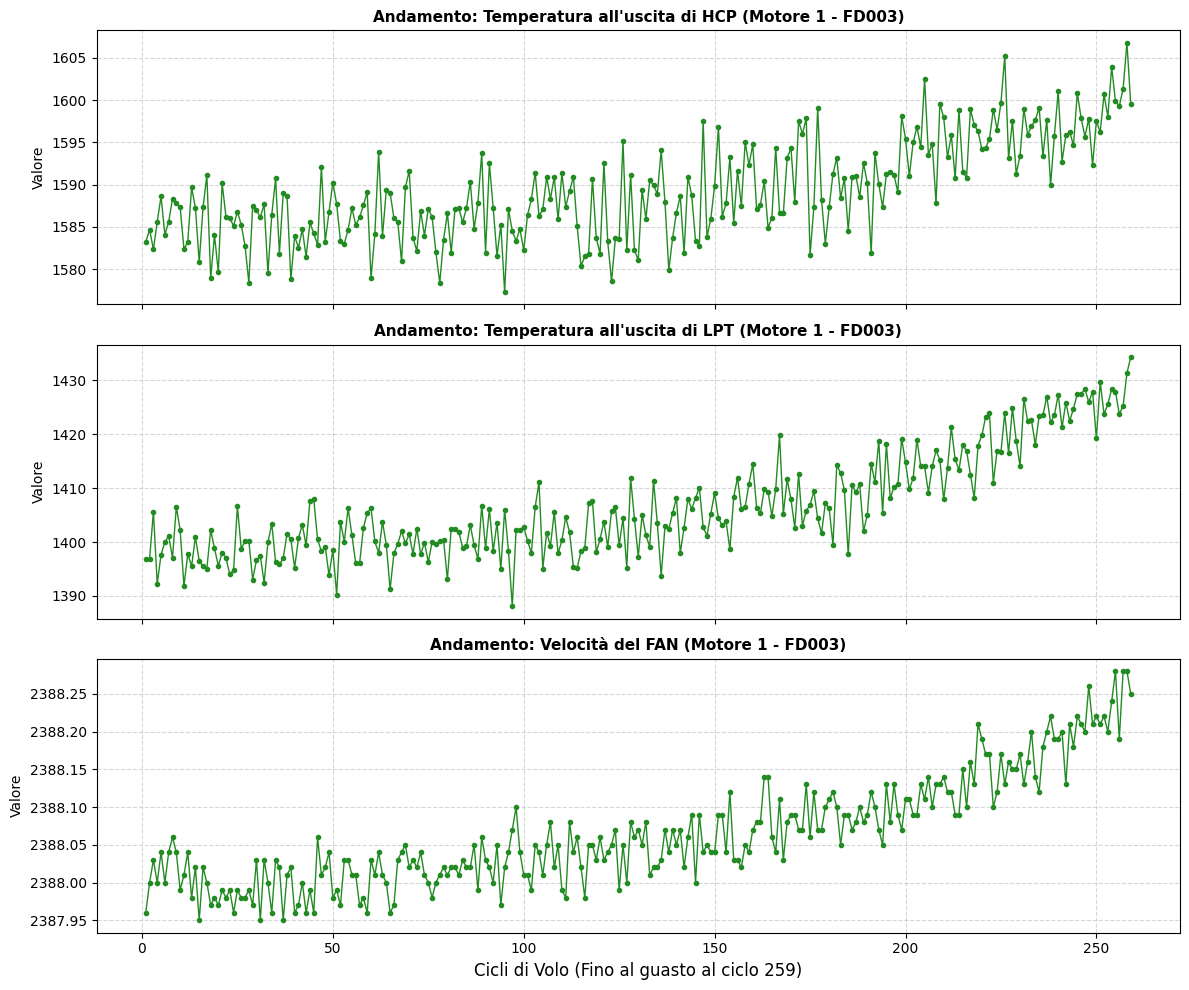

Il motore 1 di FD003 è arrivato a 259 cicli prima di rompersi.


In [60]:
import matplotlib.pyplot as plt

# more 1 fi fd003
motore_1 = df_train[df_train['id_motore'] == 1]

#sensorri per HPC e LPT
sensori_chiave = [
    "Temperatura all'uscita di HCP", 
    "Temperatura all'uscita di LPT", 
    "Velocità del FAN"
]

# grafici al variare dei cicli
fig, assi = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

for i, sensore in enumerate(sensori_chiave):
    # Tracciamo i dati (qui puliti perché c'è un solo regime di volo)
    assi[i].plot(motore_1['ciclo'], motore_1[sensore], color='forestgreen', marker='o', markersize=3, linewidth=1)
    
    assi[i].set_title(f"Andamento: {sensore} (Motore 1 - FD003)", fontsize=11, fontweight='bold')
    assi[i].set_ylabel("Valore")
    assi[i].grid(True, linestyle='--', alpha=0.5)

# L'asse X mostra la durata totale del motore 1
cicli_totali = motore_1['ciclo'].max()
assi[-1].set_xlabel(f"Cicli di Volo (Fino al guasto al ciclo {cicli_totali})", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Il motore 1 di FD003 è arrivato a {cicli_totali} cicli prima di rompersi.")

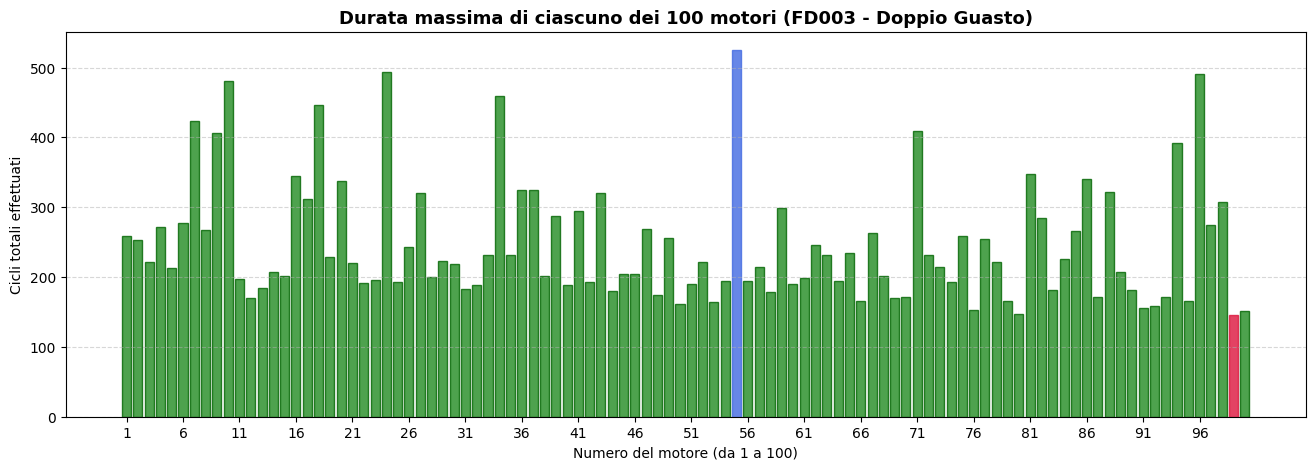

Riepilogo dati flotta FD003:
- Il motore che è durato MENO è il numero 99 (si è rotto a 145 cicli).
- Il motore che è durato DI PIÙ è il numero 55 (è arrivato a 525 cicli).
- In media, i motori in FD003 resistono per 247.2 cicli.


In [61]:
import matplotlib.pyplot as plt

# 1. Calcoliamo la durata massima per ogni motore
durata_003 = df_train.groupby('id_motore')['ciclo'].max()

# 2. Troviamo i motori estremi
motore_min = durata_003.idxmin()
cicli_min = durata_003.min()

motore_max = durata_003.idxmax()
cicli_max = durata_003.max()

media_cicli = durata_003.mean()

# 3. Grafico a barre
plt.figure(figsize=(16, 5))
barre = plt.bar(durata_003.index, durata_003.values, color='forestgreen', edgecolor='darkgreen', alpha=0.8)

# Evidenziamo il più corto (rosso) e il più lungo (blu)
barre[motore_min - 1].set_color('crimson')
barre[motore_max - 1].set_color('royalblue')

plt.title("Durata massima di ciascuno dei 100 motori (FD003 - Doppio Guasto)", fontsize=13, fontweight='bold')
plt.xlabel("Numero del motore (da 1 a 100)")
plt.ylabel("Cicli totali effettuati")
plt.xticks(range(1, 101, 5))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

# 4. Statistiche
print("Riepilogo dati flotta FD003:")
print(f"- Il motore che è durato MENO è il numero {motore_min} (si è rotto a {cicli_min} cicli).")
print(f"- Il motore che è durato DI PIÙ è il numero {motore_max} (è arrivato a {cicli_max} cicli).")
print(f"- In media, i motori in FD003 resistono per {media_cicli:.1f} cicli.")

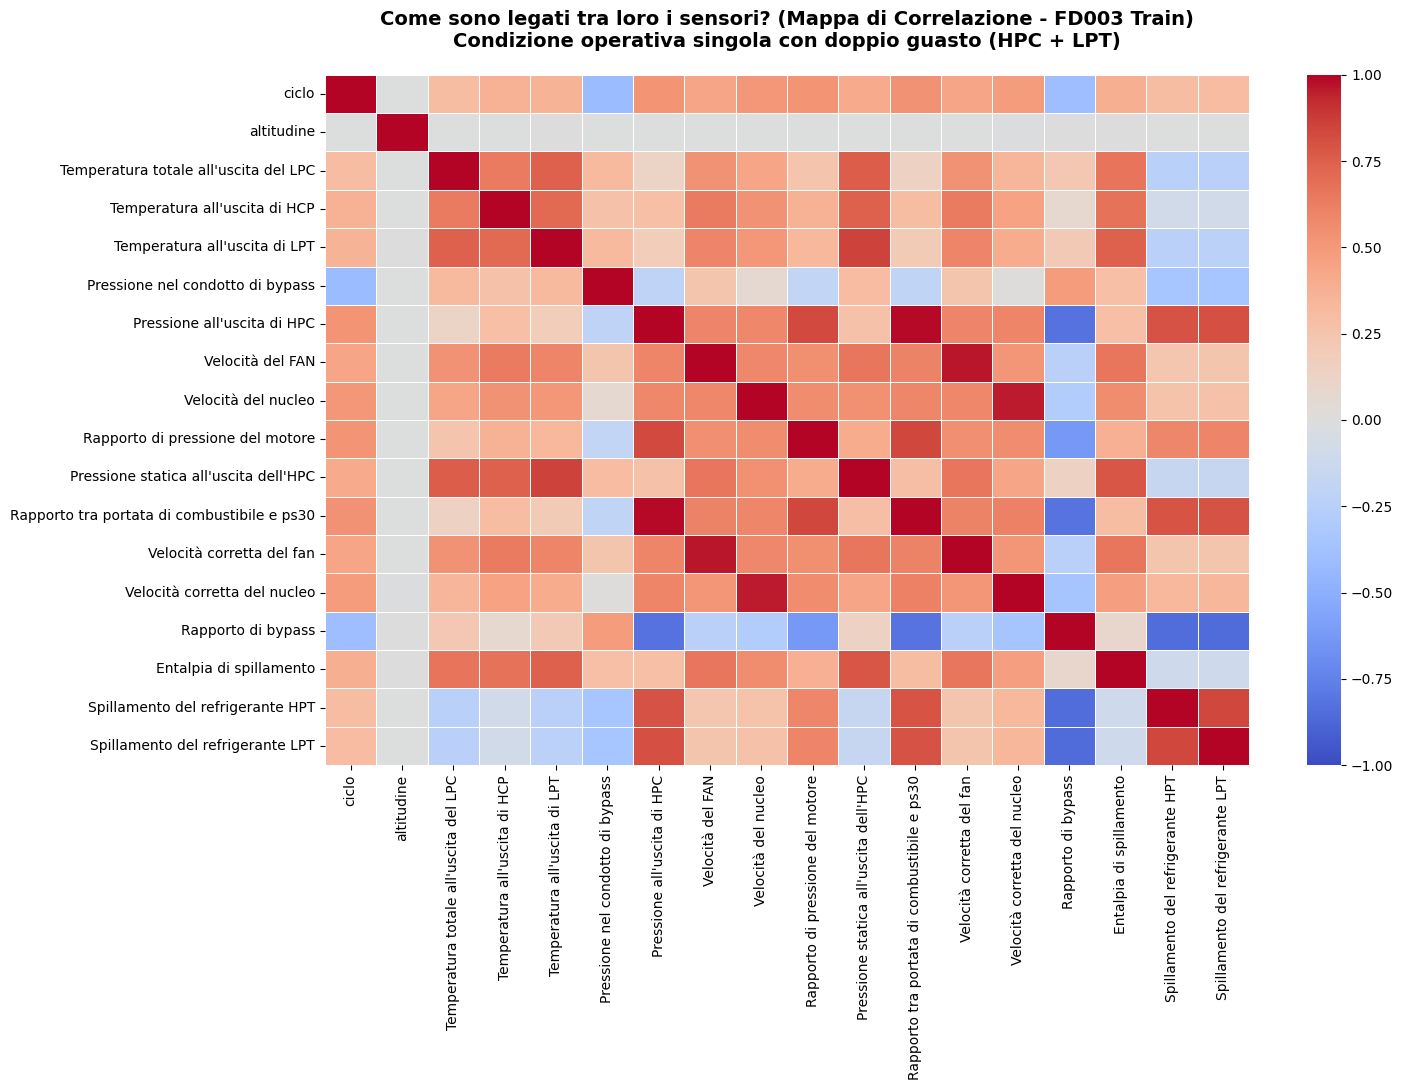

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Trova ed esclude i sensori piatti (quelli che non cambiano mai valore)
deviazioni = df_train.std()
colonne_attive = deviazioni[deviazioni > 0.001].index.tolist()

# Togliamo l'id_motore per calcolare la correlazione solo tra parametri fisici e cicli
if 'id_motore' in colonne_attive:
    colonne_attive.remove('id_motore')

# 2. Calcola la matrice di correlazione di Pearson
matrice_corr_003 = df_train[colonne_attive].corr()

# 3. Disegna la mappa di calore (Heatmap)
plt.figure(figsize=(15, 11))
sns.heatmap(
    matrice_corr_003, 
    annot=False,          # Non inseriamo i numeri per lasciarla pulita e leggibile a colpo d'occhio
    cmap='coolwarm',      # Il classico gradiente Blu (negativo) -> Bianco (zero) -> Rosso (positivo)
    vmin=-1,              # Limite minimo della correlazione
    vmax=1,               # Limite massimo della correlazione
    linewidths=0.5,       # Una linea sottile per separare i quadratini
    linecolor='white'
)

plt.title("Come sono legati tra loro i sensori? (Mappa di Correlazione - FD003 Train)\n"
          "Condizione operativa singola con doppio guasto (HPC + LPT)", 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

La mappa di correlazione di FD003 mostra il ritorno a relazioni lineari forti (colori accesi) grazie all'assenza dei cambi di quota. Si nota una fortissima interconnessione nel blocco delle temperature, causata dall'effetto combinato del degrado simultaneo su HPC e LPT.

# Analisi FD004 train
Questo è il dataset più complesso di tutti. Tutte le difficoltà dei blocchi precedenti sono state unite in un unico scenario.

### 6 Regimi di volo + Doppio guasto
Vengono messi insieme i problemi ambientali di FD002 e i problemi meccanici di FD003:
* **6 Regimi:** I motori cambiano continuamente altitudine, velocità e manetta. Tutti i sensori avranno un grafico con oscillazioni che nascondono il degrado a occhio nudo.
* **Doppio Guasto:** I motori si rompono per il cedimento simultaneo del **Compressore ad Alta Pressione (HPC)** e della **Turbina a Bassa Pressione (LPT)**.

### 2. I dati di Train
* Ci sono **249 motori** indipendenti monitorati fino al momento del guasto.
* È il file più realistico ma anche il più difficile, perché lo stesso sensore salta sia perché l'aereo cambia quota, sia perché si stanno rompendo due pezzi insieme.

In [66]:
import pandas as pd
pd.set_option('display.max_columns', None)

# Stessi identici nomi delle colonne usati finora
nomi_colonne = [
    'id_motore', 'ciclo', 'altitudine', 'velocita_mach', 'manetta_tra',
    "Temperatura all'ingresso del fan", 
    "Temperatura totale all'uscita del LPC", 
    "Temperatura all'uscita di HCP", 
    "Temperatura all'uscita di LPT", 
    "Pressione all'ingresso del FAN",
    'Pressione nel condotto di bypass', 
    "Pressione all'uscita di HPC", 
    'Velocità del FAN', 
    'Velocità del nucleo', 
    'Rapporto di pressione del motore',
    "Pressione statica all'uscita dell'HPC", 
    'Rapporto tra portata di combustibile e ps30', 
    'Velocità corretta del fan', 
    'Velocità corretta del nucleo',
    'Rapporto di bypass',
    'Rapporto aria-combustibile nel combustore', 
    'Entalpia di spillamento', 
    'Velocità del FAN richiesta', 
    'Velocità corretta del fan richiesta',
    'Spillamento del refrigerante HPT',
    'Spillamento del refrigerante LPT'
]

# Carichiamo il dataset FD004
df_train = pd.read_csv('data/train_FD004.txt', sep=r'\s+', names=nomi_colonne, header=None)
display(df_train.head())

,id_motore,ciclo,altitudine,velocita_mach,manetta_tra,Temperatura all'ingresso del fan,Temperatura totale all'uscita del LPC,Temperatura all'uscita di HCP,Temperatura all'uscita di LPT,Pressione all'ingresso del FAN,Pressione nel condotto di bypass,Pressione all'uscita di HPC,Velocità del FAN,Velocità del nucleo,Rapporto di pressione del motore,Pressione statica all'uscita dell'HPC,Rapporto tra portata di combustibile e ps30,Velocità corretta del fan,Velocità corretta del nucleo,Rapporto di bypass,Rapporto aria-combustibile nel combustore,Entalpia di spillamento,Velocità del FAN richiesta,Velocità corretta del fan richiesta,Spillamento del refrigerante HPT,Spillamento del refrigerante LPT
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


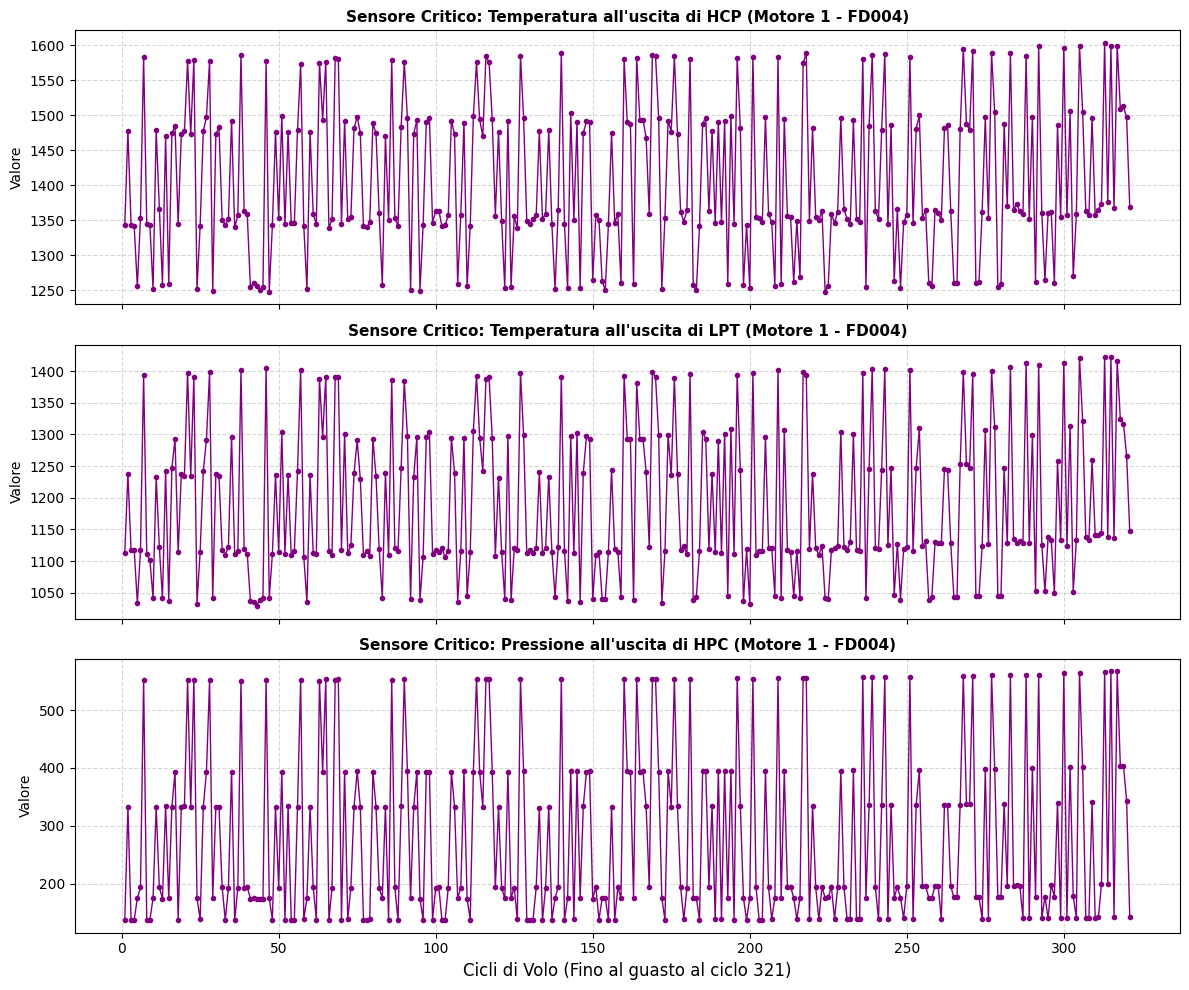

Il motore 1 di FD004 si è rotto dopo 321 cicli.


In [67]:
import matplotlib.pyplot as plt

# motore 1 di FD004
motore_1 = df_train[df_train['id_motore'] == 1]

#sensori critici per HPC e LPT
sensori_mostro = [
    "Temperatura all'uscita di HCP", 
    "Temperatura all'uscita di LPT", 
    "Pressione all'uscita di HPC"
]

# grafici
fig, assi = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

for i, sensore in enumerate(sensori_mostro):
    # Usiamo una linea viola per distinguere questo dataset dagli altri
    assi[i].plot(motore_1['ciclo'], motore_1[sensore], color='purple', marker='o', markersize=3, linewidth=1)
    
    assi[i].set_title(f"Sensore Critico: {sensore} (Motore 1 - FD004)", fontsize=11, fontweight='bold')
    assi[i].set_ylabel("Valore")
    assi[i].grid(True, linestyle='--', alpha=0.5)

cicli_totali = motore_1['ciclo'].max()
assi[-1].set_xlabel(f"Cicli di Volo (Fino al guasto al ciclo {cicli_totali})", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Il motore 1 di FD004 si è rotto dopo {cicli_totali} cicli.")

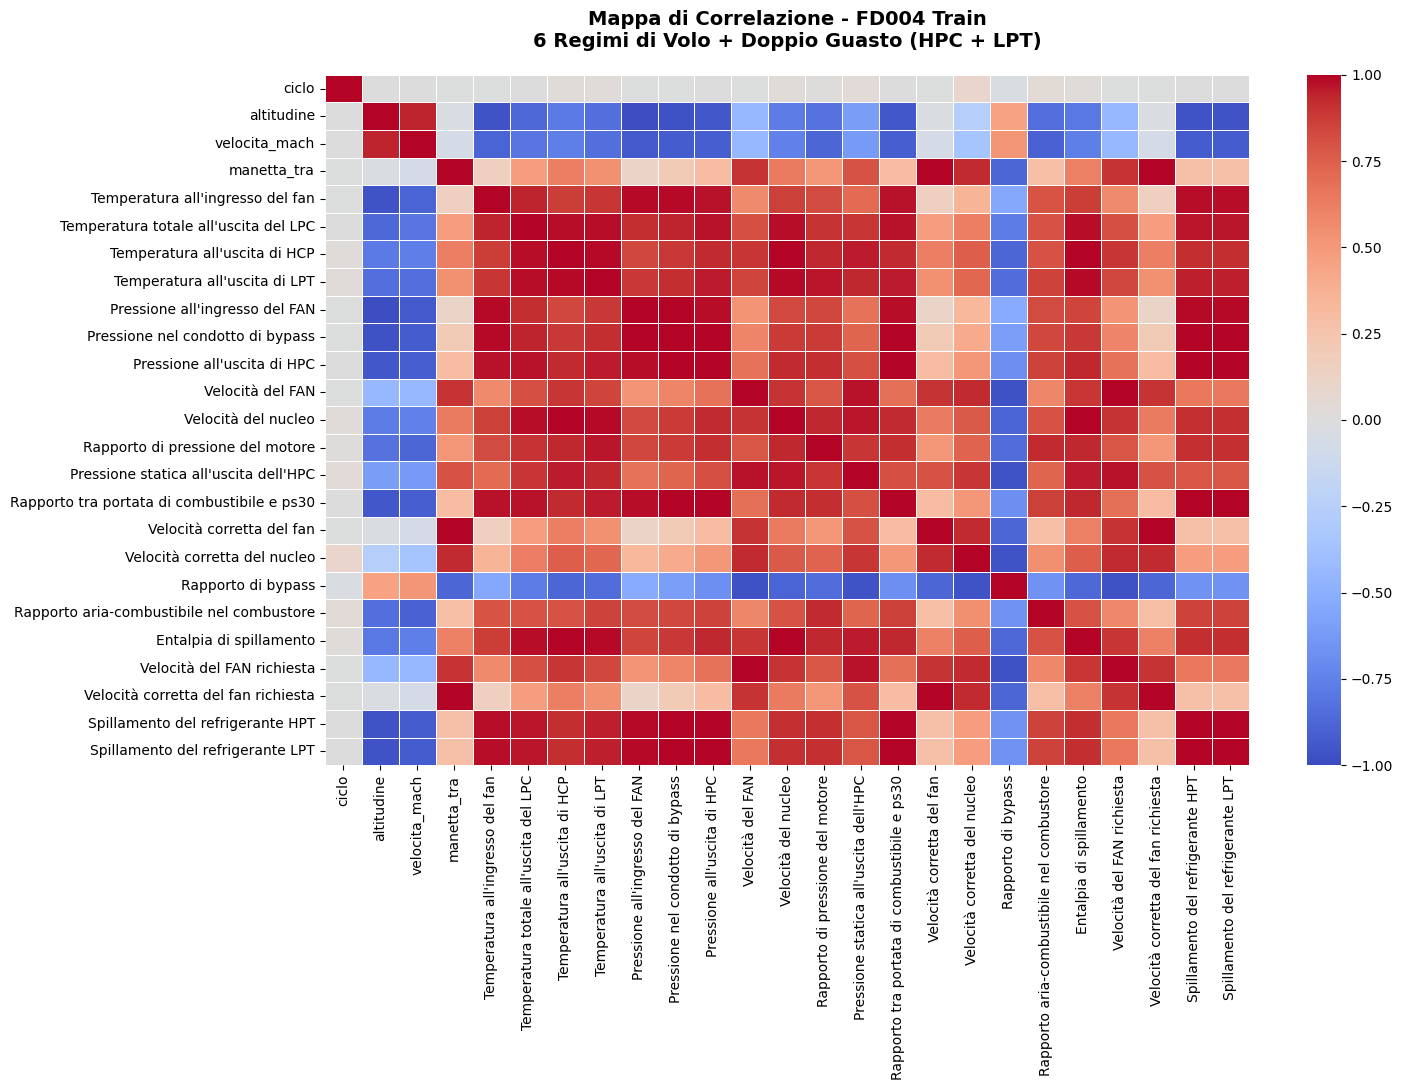

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Escludiamo l'id_motore per concentrarci solo sulle relazioni fisiche
colonne_sensori_004 = [c for c in df_train.columns if c != 'id_motore']
matrice_corr_004 = df_train[colonne_sensori_004].corr()

# 2. Generiamo la Heatmap
plt.figure(figsize=(15, 11))
sns.heatmap(
    matrice_corr_004, 
    annot=False,          # Manteniamo la visualizzazione pulita senza numeri
    cmap='coolwarm',      # Blu (negativo), Bianco (zero), Rosso (positivo)
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    linecolor='white'
)

plt.title("Mappa di Correlazione - FD004 Train\n"
          "6 Regimi di Volo + Doppio Guasto (HPC + LPT)", 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

La mappa di FD004 ha colori molto accesi perché i cambi di quota, velocità e manetta (i 6 regimi) stravolgono completamente e in modo diretto tutti i valori dei sensori. Al contrario, la riga del 'ciclo' è l'unica sbiadita: questo dimostra che l'usura progressiva del motore è piccolissima rispetto agli sbalzi giganti del volo, rendendo il danno nascosto e invisibile a occhio nudo.